In [7]:
import scanpy as sc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata
import os
import seaborn as sb

In [8]:
level1_marker = {
    'B cell': ['CD79A', 'CD79B', 'MS4A1', 'IGKC', 'CD22', 'FCER2'],
    'Plasma cell': ['IGKC', 'IGHM', 'IGHA1', 'IGLC2', 'IGLC3', 'JCHAIN'],
    'T cell': ['CD2', 'TRAC', 'CD69', 'CD3D', 'CD3E', 'CD4', 'CD8A', 'CD8B', 'EOMES', 'LAG3'],
    'Natural killer cell': ['NKG7', 'XCL1', 'CTSW', 'XCL2', 'CD160', 'FCGR3A', 'PRF1', 'GNLY'],
    'Dendritic cell': ['CLEC10A', 'FCER1A', 'CD1C', 'HLA-DRA', 'HLA-DRB1'],
    'Endothelial cell': ['PECAM1', 'VWF', 'FABP4', 'CLDN5', 'IFI27', 'ECSCR', 'DYSF', 'CD34', 'COL4A1', 'COL4A2', 'SPARCL1', 'PLVAP', 'MPZL2', 'SULF1', 'EDN1'],
    'Fibroblast': ['LUM', 'DCN', 'COL1A1', 'COL1A2', 'FBLN1','C3','C7', 'THY1'],##C3;C7
    'Fibromyocyte': ['FN1', 'LUM', 'TNFRSF11B', 'ACTA2', 'TCF21'],
    'Smooth muscle cell': ['ACTA2', 'MYH11', 'MYL9', 'TPM2', 'CALD1', 'TAGLN', 'TNFRSF11B', 'LUM', 'APOE', 'APOC1', 'AGT', 'NOTCH3', 'PDGFRB', 'MFAP4'],
    'Macrophage': ['C1QA', 'C1QB', 'C1QC', 'CD74', 'CXCL8', 'AIF1', 'CD14', 'CD68', 'ITGAM', 'CSF1R', 'HLA-DRA', 'LGALS3'],
    'Monocyte': ['FCN1', 'S100A8', 'S100A9', 'S100A12', 'VCAN', 'CD52', 'LYZ', 'CTSS'],
    'Mast cell': ['TPSAB1', 'TPSB2', 'KIT', 'HDC', 'CMA1'],
    'Neutrophil':['NAMPT','IFITM2','G0S2','CXCL8','NEAT1','SRGN','AQP9','SOD2','FCGR3B','IVNS1ABP']
}

In [9]:
# 包含none
# level1_marker_mouse = {
#     'Bcell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2a'],
#     'Plasma cell': ['Igkc', 'Ighm', 'Igha', 'Iglc2', 'Iglc2', 'Jchain'],
#     'Tcell': ['Cd2', None, 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'NK': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl1', 'Cd160', 'Fcgr4', 'Prf1', None],
#     'DC': ['Mgl2', 'Fcer1a', None, 'H2-Ea', 'H2-Eb2'],
#     'cdc1': ['Clec9a', 'Irf8', 'Snx3'],
#     'cdc2': [None, 'Mgl2', 'Fcer1a'],
#     'mature dc': ['Cd40', 'Cd200', 'Tnfrsf4', 'Cd274', None, 'Marcksl1', 'Ido1'],
#     'pDC': ['Clec4a3', 'Pirb', None, 'Tcf4', 'Tcl1', 'Spib', 'Gzmc', 'Nrp1', 'Irf7', 'Irf8', 'Slc15a4'],
#     'EC': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', None, None, 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1', 'C3', 'C7'],
#     'Fibromyocyte': ['Fn1', 'Lum', 'Tnfrsf11b', 'Acta2', 'Tcf21'],
#     'Fibromyocyte_miller': ['Fn1', 'Vcan', 'Ltbp1', 'Col4a2', 'Col6a2'],
#     'SMC': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', None, 'Aif1', 'Cd14', None, 'Itgam', 'Csf1r', 'H2-Ea', 'Lgals3'],
#     'Monocyte': ['Fcnb', 'S100a8', 'Gm5849', None, 'Vcan', 'Cd52', 'Lyz1', 'Ctss'],
#     'Mast': ['Tpsab1', 'Tpsab1', 'Kit', 'Hdc', 'Cma1'],
#     'Neuron': ['Plp1'],
#     'Neutrophil': ['Nampt', 'Ifitm7', 'G0s2', None, None, 'Srgn', 'Aqp9', 'Not found', 'Fcgr4', 'Ivns1abp']
# }
# }

In [10]:
# level1_marker_mouse = {
#     'Bcell': ['Cd79a', 'Cd79b', 'Ms4a1', 'Igkc', 'Cd22', 'Fcer2a'],
#     'Plasma cell': ['Igkc', 'Ighm', 'Igha', 'Iglc2', 'Iglc2', 'Jchain'],
#     'Tcell': ['Cd2', 'Cd69', 'Cd3d', 'Cd3e', 'Cd4', 'Cd8a', 'Cd8b1', 'Eomes', 'Lag3'],
#     'NK': ['Nkg7', 'Xcl1', 'Ctsw', 'Xcl1', 'Cd160', 'Fcgr4', 'Prf1'],
#     'DC': ['Mgl2', 'Fcer1a','H2-Ea', 'H2-Eb2'],
#     'cdc1': ['Clec9a', 'Irf8', 'Snx3'],
#     'cdc2': [ 'Mgl2', 'Fcer1a'],
#     'mature dc': ['Cd40', 'Cd200', 'Tnfrsf4', 'Cd274',  'Marcksl1', 'Ido1'],
#     'pDC': ['Clec4a3', 'Pirb', 'Tcf4', 'Tcl1', 'Spib', 'Gzmc', 'Nrp1', 'Irf7', 'Irf8', 'Slc15a4'],
#     'EC': ['Pecam1', 'Vwf', 'Fabp4', 'Cldn5', 'Dysf', 'Cd34', 'Col4a1', 'Col4a2', 'Sparcl1', 'Plvap', 'Mpzl2', 'Sulf1', 'Edn1'],
#     'Fibroblast': ['Lum', 'Dcn', 'Col1a1', 'Col1a2', 'Fbln1', 'Thy1', 'C3', 'C7'],
#     'Fibromyocyte': ['Fn1', 'Lum', 'Tnfrsf11b', 'Acta2', 'Tcf21'],
#     'Fibromyocyte_miller': ['Fn1', 'Vcan', 'Ltbp1', 'Col4a2', 'Col6a2'],
#     'SMC': ['Acta2', 'Myh11', 'Myl9', 'Tpm2', 'Cald1', 'Tagln', 'Tnfrsf11b', 'Lum', 'Apoe', 'Apoc1', 'Agt', 'Notch3', 'Pdgfrb', 'Mfap4'],
#     'Macrophage': ['C1qa', 'C1qb', 'C1qc', 'Cd74', 'Aif1', 'Cd14', 'Itgam', 'Csf1r', 'H2-Ea', 'Lgals3'],
#     'Monocyte': ['Fcnb', 'S100a8', 'Gm5849',  'Vcan', 'Cd52', 'Lyz1', 'Ctss'],
#     'Mast': ['Tpsab1', 'Tpsab1', 'Kit', 'Hdc', 'Cma1'],
#     'Neuron': ['Plp1'],
#     'Neutrophil': ['Nampt', 'Ifitm7', 'G0s2',  'Srgn', 'Aqp9', 'Fcgr4', 'Ivns1abp']
# }

In [11]:
all_genes = set()
for gene_list in level1_marker.values():
    all_genes.update(gene_list)
all_genes = sorted(all_genes)

data = []
for cell_type, genes in level1_marker.items():
    row = [1 if gene in genes else 0 for gene in all_genes]
    data.append(row)

ref_df = pd.DataFrame(data, index=level1_marker.keys(), columns=all_genes)
print(ref_df)

                     ACTA2  AGT  AIF1  APOC1  APOE  AQP9  C1QA  C1QB  C1QC  \
B cell                   0    0     0      0     0     0     0     0     0   
Plasma cell              0    0     0      0     0     0     0     0     0   
T cell                   0    0     0      0     0     0     0     0     0   
Natural killer cell      0    0     0      0     0     0     0     0     0   
Dendritic cell           0    0     0      0     0     0     0     0     0   
Endothelial cell         0    0     0      0     0     0     0     0     0   
Fibroblast               0    0     0      0     0     0     0     0     0   
Fibromyocyte             1    0     0      0     0     0     0     0     0   
Smooth muscle cell       1    1     0      1     1     0     0     0     0   
Macrophage               0    0     1      0     0     0     1     1     1   
Monocyte                 0    0     0      0     0     0     0     0     0   
Mast cell                0    0     0      0     0     0     0  

In [12]:
os.chdir("/home/lixiangyu/zr/Annotate/")

## Bleckwehl et al.

In [13]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/data/human_normal_data/postQC/Article_SC_healthy_ensembl_id-postQC.h5ad")

In [14]:
adata.layers['rounded_corrected_counts'] = adata.X.copy()

In [15]:
#check how many cells have zero counts for all genes
cellwise_sum = adata.X.sum(axis=1)
num_cells_zero_counts = (cellwise_sum == 0).sum()
#remove cells with zero counts for all genes
adata = adata[cellwise_sum != 0].copy()
print(num_cells_zero_counts)

0


In [16]:
adata.var_names

Index(['AL645608.1', 'SAMD11', 'AL645608.8', 'HES4', 'ISG15', 'AL645608.2',
       'AGRN', 'TNFRSF18', 'TNFRSF4', 'B3GALT6',
       ...
       'MT-ND2', 'MT-CO1', 'MT-CO2', 'MT-ATP6', 'MT-CO3', 'MT-ND3', 'MT-ND6',
       'MT-CYB', 'AC004556.1', 'AC233755.2'],
      dtype='object', length=7823)

In [17]:
#check if the marker genes are in the data and print percentage of marker genes per celltype in the data
#also print which marker genes are not in the data
#create new dict on the way
marker_genes_in_data = {}
for celltype in level1_marker:
    marker_genes_in_data[celltype] = list(set(level1_marker[celltype]).intersection(adata.var_names))
    print(celltype, len(set(level1_marker[celltype]).intersection(adata.var_names))/len(level1_marker[celltype]))
    print("not included: ", set(level1_marker[celltype]).difference(adata.var_names))

B cell 1.0
not included:  set()
Plasma cell 1.0
not included:  set()
T cell 1.0
not included:  set()
Natural killer cell 1.0
not included:  set()
Dendritic cell 1.0
not included:  set()
Endothelial cell 1.0
not included:  set()
Fibroblast 1.0
not included:  set()
Fibromyocyte 1.0
not included:  set()
Smooth muscle cell 1.0
not included:  set()
Macrophage 1.0
not included:  set()
Monocyte 1.0
not included:  set()
Mast cell 1.0
not included:  set()
Neutrophil 1.0
not included:  set()


In [18]:
(adata.obs['sample'])

Hu_AAACCTGAGAGTTGGC-S1_CA     Bleckweh T et al.
Hu_AAACCTGAGCAGATCG-S1_CA     Bleckweh T et al.
Hu_AAACCTGAGCCATCGC-S1_CA     Bleckweh T et al.
Hu_AAACCTGAGGAGTTTA-S1_CA     Bleckweh T et al.
Hu_AAACCTGAGTCAATAG-S1_CA     Bleckweh T et al.
                                    ...        
Hu_TTTGTCAGTGAAAGAG-S3_CA2    Bleckweh T et al.
Hu_TTTGTCAGTGATGCCC-S3_CA2    Bleckweh T et al.
Hu_TTTGTCATCAGTGTTG-S3_CA2    Bleckweh T et al.
Hu_TTTGTCATCGCGCCAA-S3_CA2    Bleckweh T et al.
Hu_TTTGTCATCGGCATCG-S3_CA2    Bleckweh T et al.
Name: sample, Length: 54850, dtype: category
Categories (1, object): ['Bleckweh T et al.']

In [19]:
#Perform a clustering for scran normalization in clusters
adata_pp = adata.copy()
sc.pp.normalize_total(adata_pp, target_sum=1e6)
sc.pp.log1p(adata_pp)
sc.pp.pca(adata_pp, svd_solver="arpack")
sc.pp.neighbors(adata_pp, n_pcs=30)
sc.tl.leiden(adata_pp, key_added='groups', resolution=0.22)

In [20]:
import rpy2.rinterface_lib.callbacks
import logging

from rpy2.robjects import pandas2ri
import anndata2ri

# Ignore R warning messages
#Note: this can be commented out to get more verbose R output
rpy2.rinterface_lib.callbacks.logger.setLevel(logging.ERROR)

# Automatically convert rpy2 outputs to pandas dataframes
pandas2ri.activate()
anndata2ri.activate()
%load_ext rpy2.ipython

/tmp/ipykernel_2610869/2253401465.py:13: DeprecationWarning: The global conversion available with activate() is deprecated and will be removed in the next major release. Use a local converter.
  anndata2ri.activate()


In [21]:
#Preprocess variables for scran normalization
input_groups = adata_pp.obs['groups']
data_mat = adata.X.T 

In [22]:
%%R -i data_mat -i input_groups -o size_factors
library(scran)
library(Matrix)  # 必须加载此包以支持稀疏矩阵

print("转换稀疏格式")
data_mat <- as(data_mat, "dgCMatrix")  # 从Python的CSC转为R的CSC格式

# 计算size factors（直接操作稀疏矩阵）
size_factors <- calculateSumFactors(data_mat, clusters=input_groups, min.mean=0.1)
print("计算结束")

[1] "转换稀疏格式"
[1] "计算结束"


Loading required package: SingleCellExperiment
Loading required package: SummarizedExperiment
Loading required package: MatrixGenerics
Loading required package: matrixStats

Attaching package: ‘MatrixGenerics’

The following objects are masked from ‘package:matrixStats’:

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOr

In [23]:
del adata_pp

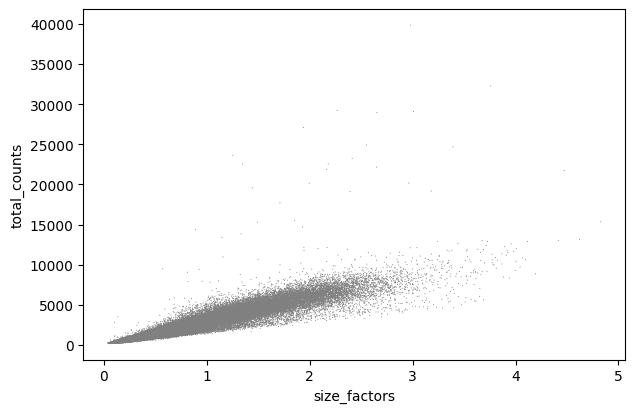

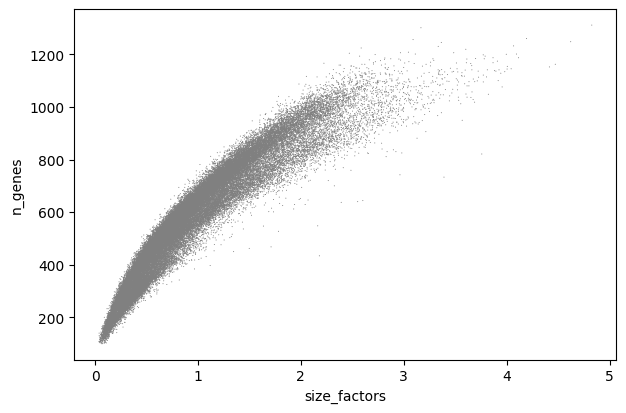

/tmp/ipykernel_2610869/1409471852.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(size_factors, bins=50, kde=False)


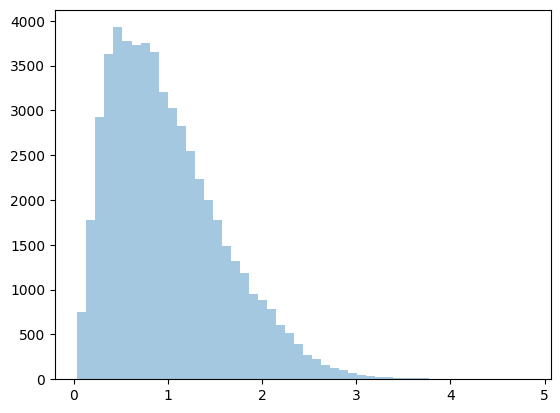

In [24]:
# Visualize the estimated size factors
adata.obs['size_factors'] = size_factors

sc.pl.scatter(adata, 'size_factors', 'total_counts')
sc.pl.scatter(adata, 'size_factors', 'n_genes')

sb.distplot(size_factors, bins=50, kde=False)
plt.show()

In [25]:
#Normalize adata 
adata.X /= adata.obs['size_factors'].values[:,None]
sc.pp.log1p(adata)

In [26]:
# high variable genes selection
sc.pp.highly_variable_genes(adata, n_top_genes=2000, subset=False)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/preprocessing/_highly_variable_genes.py:220: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  disp_grouped = df.groupby('mean_bin')['dispersions']


In [27]:
adata

AnnData object with n_obs × n_vars = 54850 × 7823
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'tissue', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'size_factors'
    var: 'ensembl_id', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'
    layers: 'rounded_corrected_counts'

In [28]:
adata.write("/home/lixiangyu/zr/Annotate/ANNOTATE_new/2_annotation/output_data_Bleckwehl/Article_SC_healthy_ensembl_id-pre_annot_r2.h5ad")

In [29]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/2_annotation/output_data_Bleckwehl/Article_SC_healthy_ensembl_id-pre_annot_r2.h5ad")

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


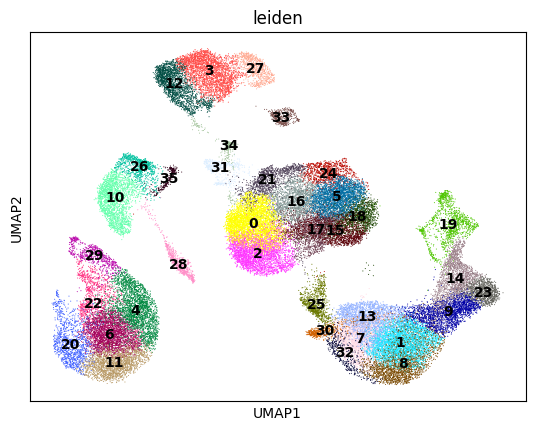

In [30]:
sc.pp.pca(adata, svd_solver="arpack", use_highly_variable=True)
sc.pp.neighbors(adata, n_pcs=30)
sc.tl.umap(adata)
sc.tl.leiden(adata, resolution = 2)
sc.pl.umap(adata, color= ['leiden'], ncols=1, legend_loc='on data')

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:168: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs_bool.groupby(level=0).sum() / obs_bool.groupby(level=0).count()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:178: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  dot_color_df = self.obs_tidy.groupby(level=0).mean()
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot

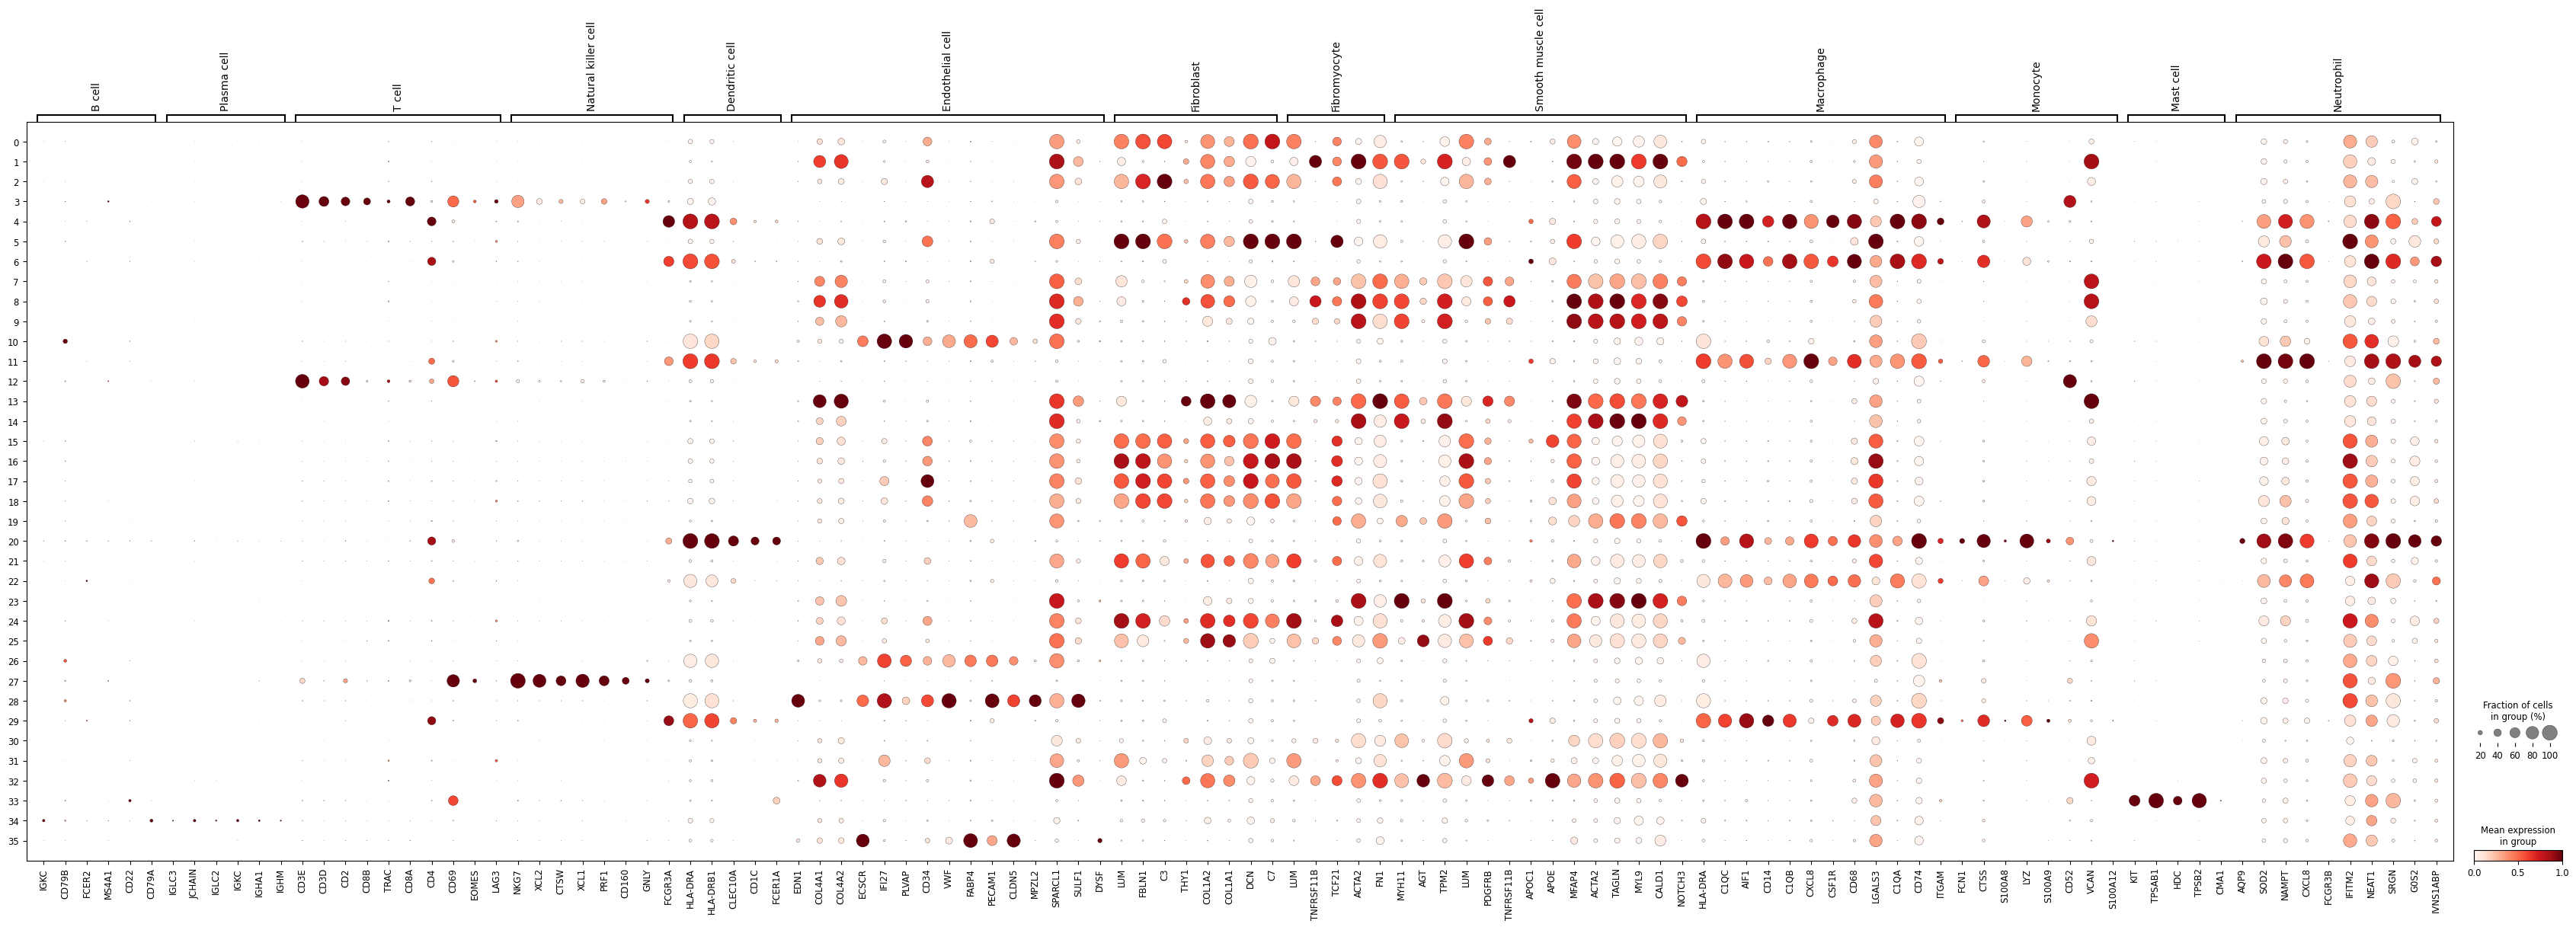

In [31]:
sc.pl.dotplot(
    adata,
    groupby="leiden",
    var_names=marker_genes_in_data,
    standard_scale="var",  # standard scale: normalize each gene to range from 0 to 1
    # save="1_JD.png",
)

In [32]:
##genes_mean
all_marker_genes = []
for gene_list in marker_genes_in_data.values():
    all_marker_genes.extend(gene_list)
all_marker_genes = [gene for gene in all_marker_genes if gene in adata.var_names]

all_marker_genes = list(set(all_marker_genes))
print(len(all_marker_genes))

105


In [33]:
leiden_clusters = adata.obs["leiden"].cat.categories
mean_expression = np.zeros((len(leiden_clusters), len(all_marker_genes)))

for i, cluster in enumerate(leiden_clusters):
    cluster_cells = adata.obs["leiden"] == cluster
    cluster_adata = adata[cluster_cells, :]
    for j, gene in enumerate(all_marker_genes):
        mean_expression[i, j] = np.mean(cluster_adata[:, gene].X)

In [34]:
df = pd.DataFrame(mean_expression, index=leiden_clusters, columns=all_marker_genes)
# csv_file_path = '/home/lixiangyu/zr/Annotate/output_data/1-JD/output/gene_expression_mean.csv'
# df.to_csv(csv_file_path)
# print(df)

In [35]:
# 确保 df 和 ref_df 有共同的基因
common_genes = df.columns.intersection(ref_df.columns)
df = df[common_genes]
ref_df = ref_df[common_genes]

In [36]:
##DISCO-CELLiD------coarse
from scipy.stats import spearmanr
first_round_results = {}
for cluster in df.index:
    cluster_expression = df.loc[cluster]
    correlations = []
    for ref_cell_type in ref_df.index:
        ref_expression = ref_df.loc[ref_cell_type]
        corr, _ = spearmanr(cluster_expression, ref_expression)
        correlations.append((ref_cell_type, corr))
    
    correlations.sort(key=lambda x: x[1], reverse=True)
    retained_types = [ct for ct, corr in correlations if corr > 0.6 or ct in [x[0] for x in correlations[:5]]]
    first_round_results[cluster] = retained_types

In [37]:
##DISCO-CELLiD------fine

second_round_results = {}
for cluster, retained_types in first_round_results.items():
    if len(retained_types) > 0:
        retained_ref_df = ref_df.loc[retained_types]
        variances = retained_ref_df.var()
        top_genes = variances.nlargest(3000).index
        cluster_expression = df.loc[cluster][top_genes]
        retained_ref_df = retained_ref_df[top_genes]
        #spearmanr
        correlations = []
        for ref_cell_type in retained_types:
            ref_expression = retained_ref_df.loc[ref_cell_type]
            corr, _ = spearmanr(cluster_expression, ref_expression)
            correlations.append((ref_cell_type, corr))
        #the highest correlation
        best_cell_type = max(correlations, key=lambda x: x[1])[0]
        second_round_results[cluster] = best_cell_type
    else:
        second_round_results[cluster] = None
# result
print("细胞类型预测结果：")
for cluster, cell_type in second_round_results.items():
    print(f"细胞簇 {cluster} 的预测细胞类型：{cell_type}")

细胞类型预测结果：
细胞簇 0 的预测细胞类型：Fibroblast
细胞簇 1 的预测细胞类型：Smooth muscle cell
细胞簇 2 的预测细胞类型：Fibroblast
细胞簇 3 的预测细胞类型：T cell
细胞簇 4 的预测细胞类型：Macrophage
细胞簇 5 的预测细胞类型：Fibroblast
细胞簇 6 的预测细胞类型：Macrophage
细胞簇 7 的预测细胞类型：Smooth muscle cell
细胞簇 8 的预测细胞类型：Smooth muscle cell
细胞簇 9 的预测细胞类型：Smooth muscle cell
细胞簇 10 的预测细胞类型：Endothelial cell
细胞簇 11 的预测细胞类型：Macrophage
细胞簇 12 的预测细胞类型：T cell
细胞簇 13 的预测细胞类型：Smooth muscle cell
细胞簇 14 的预测细胞类型：Smooth muscle cell
细胞簇 15 的预测细胞类型：Fibroblast
细胞簇 16 的预测细胞类型：Fibroblast
细胞簇 17 的预测细胞类型：Fibroblast
细胞簇 18 的预测细胞类型：Fibroblast
细胞簇 19 的预测细胞类型：Smooth muscle cell
细胞簇 20 的预测细胞类型：Macrophage
细胞簇 21 的预测细胞类型：Fibroblast
细胞簇 22 的预测细胞类型：Macrophage
细胞簇 23 的预测细胞类型：Smooth muscle cell
细胞簇 24 的预测细胞类型：Fibroblast
细胞簇 25 的预测细胞类型：Smooth muscle cell
细胞簇 26 的预测细胞类型：Endothelial cell
细胞簇 27 的预测细胞类型：Natural killer cell
细胞簇 28 的预测细胞类型：Endothelial cell
细胞簇 29 的预测细胞类型：Macrophage
细胞簇 30 的预测细胞类型：Smooth muscle cell
细胞簇 31 的预测细胞类型：Smooth muscle cell
细胞簇 32 的预测细胞类型：Smooth muscle cell
细胞簇 33 的预测细胞类型：Mast cell
细胞

In [47]:
cluster_annotation1 = {
    "0": "Fibroblast",
    "1": "Fibromyocyte",
    "2": "Fibroblast",
    "3": "T cell",
    "4": "Macrophage",
    "5": "Fibroblast",
    "6": "Macrophage", 
    "7": "Smooth muscle cell",##or SMC
    "8": "Smooth muscle cell",
    "9": "Smooth muscle cell",
    "10": "Endothelial cell",
    "11": "Neutrophil",#or Macrophage
    "12": "T cell", 
    "13": "Smooth muscle cell",
    "14": "Smooth muscle cell",
    "15": "Fibroblast", 
    "16": "Fibroblast",
    "17": "Fibroblast",
    "18": "Fibroblast",
    "19": "Smooth muscle cell",
    "20": "Dendritic cell",
    "21": "Fibroblast",
    "22": "Neutrophil",
    "23": "Smooth muscle cell",
    "24": "Fibroblast",
    "25": "Fibroblast",
    "26": "Endothelial cell",
    "27": "Natural killer cell",
    "28": "Endothelial cell",
    "29": "Macrophage",
    "30": "Smooth muscle cell",
    "31": "Fibroblast",
    "32": "Smooth muscle cell",
    "33": "Mast cell",
    "34": "T cell",
    "35": "Endothelial cell"
}

In [48]:
adata.obs["cell_type_level1"] = adata.obs.leiden.map(cluster_annotation1)

/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:1251: FutureWarning: The default value of 'ignore' for the `na_action` parameter in pandas.Categorical.map is deprecated and will be changed to 'None' in a future version. Please set na_action to the desired value to avoid seeing this warning
  color_vector = pd.Categorical(values.map(color_map))
/home/lixiangyu/anaconda3/envs/zr_r420/lib/python3.9/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


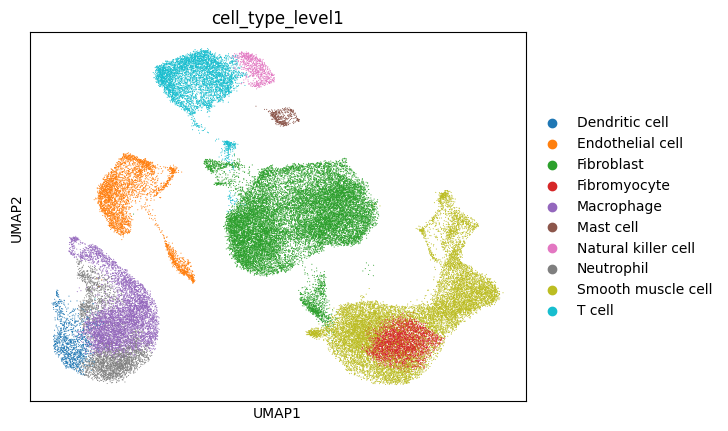

In [49]:
sc.pl.umap(adata, color= ['cell_type_level1'], ncols=1)

In [50]:
adata.write_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/2_annotation/output_data_Bleckwehl/Article_SC_healthy_ensembl_id-annoted-r2.h5ad")

In [51]:
adata.obs['cell_type_level1'].value_counts()

cell_type_level1
Fibroblast             18404
Smooth muscle cell     13148
Macrophage              5565
T cell                  4923
Endothelial cell        3852
Fibromyocyte            3509
Neutrophil              3130
Dendritic cell          1182
Natural killer cell      739
Mast cell                398
Name: count, dtype: int64